# Layer 3: linking PFF tracking data to the StatsBomb passes

The supervisor feedback after Progress Presentation 4 asked for RQ3 to be answered with the PFF FC tracking data, in two ways:

1. Are the LSTM's predicted positions accurate?
2. Could the pass actually be played to the predicted position?

The PFF data covers all 64 matches of the 2022 World Cup, which are also the 64 World Cup matches in the StatsBomb set. Unlike the 360 freeze frames, PFF identifies every player and gives positions about 30 times a second.

This notebook does the groundwork the later PFF notebooks need:

- loads the PFF metadata, events and passes;
- matches each StatsBomb World Cup match to its PFF game;
- links each StatsBomb pass to the same pass in PFF;
- checks that the link and the coordinate conversion are right;
- saves the link tables.

The helper functions are in `src/pff.py`. Nothing here changes any earlier result.

**PFF coordinates.**

- Metres, with the origin at the centre spot.
- x runs along the touchlines (plus or minus 52.5) and y across the pitch (plus or minus 34), as seen by the main camera.
- Each event carries the attacking direction of the team in possession.

`pff.pff_to_sb` converts any PFF position into StatsBomb yards, with the team in possession attacking toward x = 120, the same convention as every other notebook.

In [1]:
import sys, os, time, unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.join('..', 'src'))
import importlib
import pff
importlib.reload(pff)

RESULTS = os.path.join('..', 'data', 'results')
FIGURES = os.path.join(RESULTS, 'figures')
os.makedirs(FIGURES, exist_ok=True)

## 1. PFF metadata

One file per game with the teams, date, frame rate and pitch size.

In [2]:
meta = pff.load_metadata()
print(len(meta), 'PFF games')
print('frame rates:', meta['fps'].value_counts().to_dict())
print('pitch sizes (m):', meta[['pitch_length', 'pitch_width']].value_counts().to_dict())
meta.head()

64 PFF games
frame rates: {29.97: 64}
pitch sizes (m): {(105.0, 68.0): 64}


,pff_game_id,home_team,away_team,date,fps,home_start_left,pitch_length,pitch_width
0,3812,Senegal,Netherlands,2022-11-21T16:00:00,29.97,False,105.0,68.0
1,3813,England,Iran,2022-11-21T13:00:00,29.97,True,105.0,68.0
2,3814,Qatar,Ecuador,2022-11-20T16:00:00,29.97,True,105.0,68.0
3,3815,United States,Wales,2022-11-21T19:00:00,29.97,True,105.0,68.0
4,3816,Argentina,Saudi Arabia,2022-11-22T10:00:00,29.97,True,105.0,68.0


**What this shows:** all 64 games are there, every one recorded at 29.97 frames per second on a 105 by 68 m pitch. So one frame is about 0.033 s, and a single pitch size can be used throughout the conversion.

## 2. PFF passes, player visibility and better options

This loads the PFF event file for every game and keeps the passes and crosses. Two things are counted along the way:

- **Teammate visibility at each pass.** Every player in a PFF snapshot is marked VISIBLE (tracked on camera) or ESTIMATED (off screen, position guessed by the tracking provider). Only VISIBLE positions can serve as ground truth for checking the LSTM.
- **Better options.** PFF analysts record when a player missed a better option, what it was (P = pass, H = hold, B = carry, and so on) and, for a pass, which teammate. This is an expert-labelled version of the RQ2 question, used in a later notebook.

Takes a minute or two (64 event files of about 15 to 20 MB each).

In [3]:
t0 = time.time()
pass_tables, vis_rows = [], []
for gid in meta['pff_game_id']:
    events = pff.load_events(gid)
    pass_tables.append(pff.pff_passes(gid, events))
    for e in events:
        pe = e.get('possessionEvents') or {}
        if pe.get('possessionEventType') != 'PA':
            continue
        home = (e.get('gameEvents') or {}).get('homeTeam')
        team = e.get('homePlayers') if home else e.get('awayPlayers')
        for p in team or []:
            vis_rows.append(p.get('visibility'))

pff_all = pd.concat(pass_tables, ignore_index=True)
vis = pd.Series(vis_rows)
print(f'{len(pff_all)} PFF passes and crosses ({time.time() - t0:.0f}s)')
print(pff_all['event_type'].value_counts().to_dict())
print()
print('passing team at PFF passes:')
print((vis.value_counts(normalize=True) * 100).round(1).to_dict(), f'({len(vis)} player positions)')
print()
print('better options recorded on passes and crosses:')
print(pff_all['better_option_type'].value_counts().to_dict())
bo_pass = pff_all[pff_all['better_option_type'] == 'P']
print(f"better option = pass: {len(bo_pass)}, with the better-option teammate given: {bo_pass['better_option_player_id'].notna().sum()}")

C:\Users\raees\AppData\Local\Temp\ipykernel_25804\2337689231.py:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pff_all = pd.concat(pass_tables, ignore_index=True)


69127 PFF passes and crosses (13s)
{'PA': 66715, 'CR': 2412}

passing team at PFF passes:
{'VISIBLE': 58.0, 'ESTIMATED': 42.0} (733857 player positions)

better options recorded on passes and crosses:
{'P': 209, 'H': 59, 'L': 30, 'B': 14, 'C': 9, 'O': 9, 'S': 6}
better option = pass: 209, with the better-option teammate given: 208


**What this shows**

PFF has 66715 passes and 2412 crosses over the 64 games.

**Off-screen positions are estimated, not measured.** At PFF's pass moments, 58.0 percent of the passing team's player positions are VISIBLE and 42.0 percent are ESTIMATED. PFF's tracking also comes from broadcast video, so players outside the camera view are placed "from context" by the tracking provider. The LSTM check in the next notebook therefore scores predictions only against VISIBLE positions. Otherwise the LSTM would be judged against another model's guess.

**Better options are rare but usable.** Analysts flagged a better option on 336 passes and crosses. In 209 of them the better option was another pass, and all but one name the teammate. That is about 0.3 percent of passes, far below the RQ2 rate of 38.9 percent. The analysts chart only clear, coachable mistakes, while RQ2 counts any visible, onside, completable forward option with a higher value. So the two are expected to differ in rate. The useful question for later is whether they point to the same passes and the same teammates.

## 3. Matching games and linking passes

**Games.** The StatsBomb World Cup matches are taken from the RQ2 pass-level table (competition = World Cup 2022). Team names are identical in both providers, so each match is found by its pair of teams. Croatia against Morocco was played twice (group stage and third-place play-off). For that pair both PFF games are tried, and the one that links more passes is kept.

**Passes.** For each match, `pff.link_passes`:

1. finds the clock offset between the two providers in each period, as the most common time difference between same-team passes (works for extra time too);
2. links passes on team, time (within 3 s) and start location (within 20 yd);
3. learns which StatsBomb player is which PFF player by majority vote over those links;
4. links again, now also requiring the passer to agree wherever the player is known, one-to-one, preferring the smallest time difference plus distance / 10.

Takes about a minute.

In [4]:
pl = pd.read_pickle(os.path.join(RESULTS, 'rq2_risk_context_pass_level.pkl'))
pl['match_id'] = pl['match_id'].astype(int)
wc_ids = sorted(pl.loc[pl['competition'] == 'World Cup 2022', 'match_id'].unique())
print(len(wc_ids), 'StatsBomb World Cup matches')

pairs = {}
for _, r in meta.iterrows():
    pairs.setdefault(frozenset([r['home_team'], r['away_team']]), []).append(r['pff_game_id'])

t0 = time.time()
link_tables, match_rows = [], []
for mid in wc_ids:
    ev = pd.read_pickle(os.path.join('..', 'data', 'statsbomb_cache', f'events_{mid}.pkl'))
    candidates = pairs[frozenset(ev['team'].dropna().unique())]
    best = None
    for gid in candidates:
        links, _ = pff.link_passes(ev, pff_all[pff_all['pff_game_id'] == gid])
        if best is None or len(links) > len(best[1]):
            best = (gid, links)
    gid, links = best
    links['match_id'] = mid
    links['pff_game_id'] = gid
    link_tables.append(links)
    n_sb = int((ev['type'] == 'Pass').sum())
    match_rows.append({'match_id': mid, 'pff_game_id': gid, 'n_candidates': len(candidates),
                       'teams': ' v '.join(sorted(ev['team'].dropna().unique())),
                       'sb_passes': n_sb, 'linked': len(links), 'rate': len(links) / n_sb,
                       'periods': len(links['period'].unique())})

links = pd.concat(link_tables, ignore_index=True)
match_map = pd.DataFrame(match_rows)
print(f'done in {time.time() - t0:.0f}s')
print('every PFF game used once:', match_map['pff_game_id'].is_unique)
print(match_map[match_map['n_candidates'] > 1])

64 StatsBomb World Cup matches
done in 16s
every PFF game used once: True
    match_id  pff_game_id  n_candidates              teams  sb_passes  linked  \
23   3857277         3820             2  Croatia v Morocco       1070     991   
62   3869684        10516             2  Croatia v Morocco       1040     937   

        rate  periods  
23  0.926168        2  
62  0.900962        2  


**What this shows:** every StatsBomb World Cup match found exactly one PFF game, and no PFF game was used twice. For the two Croatia against Morocco matches, each StatsBomb match linked far more passes to one of the two PFF games than to the other, so the pairing is unambiguous.

StatsBomb passes linked: 61635 of 68515 (90.0%)
per match link rate: {'min': 0.82, '25%': 0.887, '50%': 0.902, '75%': 0.917, 'max': 0.939}
matches with extra time linked in all 4 periods: 5

time difference: median 0.06s, 90th percentile 0.21s
start location distance: median 3.9 yd, 90th percentile 8.3 yd


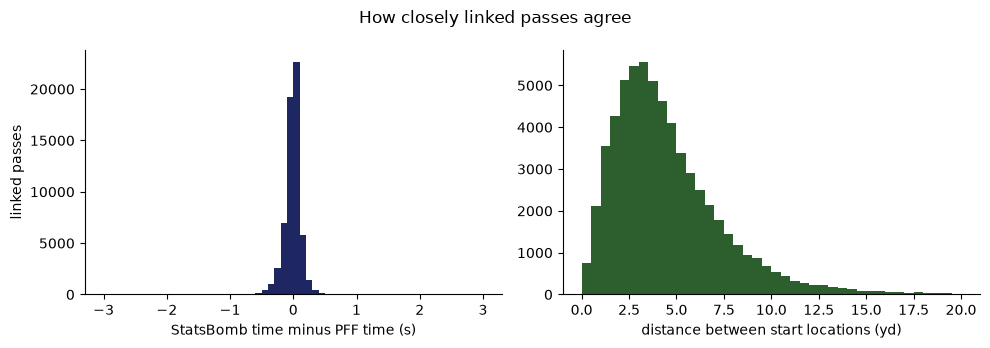

In [5]:
print(f"StatsBomb passes linked: {len(links)} of {match_map['sb_passes'].sum()} "
      f"({len(links) / match_map['sb_passes'].sum():.1%})")
print('per match link rate:', match_map['rate'].describe()[['min', '25%', '50%', '75%', 'max']].round(3).to_dict())
print('matches with extra time linked in all 4 periods:', int((match_map['periods'] == 4).sum()))
print()
print(f"time difference: median {links['dt'].abs().median():.2f}s, 90th percentile {links['dt'].abs().quantile(0.9):.2f}s")
print(f"start location distance: median {links['dist_yd'].median():.1f} yd, 90th percentile {links['dist_yd'].quantile(0.9):.1f} yd")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(links['dt'], bins=np.arange(-3, 3.05, 0.1), color='#1E2761')
axes[0].set_xlabel('StatsBomb time minus PFF time (s)')
axes[0].set_ylabel('linked passes')
axes[1].hist(links['dist_yd'], bins=np.arange(0, 20.5, 0.5), color='#2C5F2D')
axes[1].set_xlabel('distance between start locations (yd)')
for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
fig.suptitle('How closely linked passes agree')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'pff_link_quality.png'), dpi=200, bbox_inches='tight')
plt.show()

**What this shows**

**90.0 percent of StatsBomb passes are linked:** 61635 of 68515 over the 64 matches. Every match falls between 82 and 94 percent (median 90). All five matches with extra time are linked in all four periods.

**The links are tight.** Linked passes are a median 0.06 s apart (90 percent within 0.21 s). Their start locations are a median 3.9 yd apart (90 percent within 8.3 yd). The location gap is mostly a difference in definition, not an error. StatsBomb records where the passer struck the ball. PFF's event snapshot places the ball from broadcast tracking, which is estimated when the ball is in the air or off screen.

## 4. Checks: coordinates and passers

Two independent checks that the links are the right passes.

- **Coordinates.** If `pff_to_sb` is right, linked start locations should be closest under the conversion used. They should be much further apart under two plausible mistakes: forgetting that PFF's y axis points the other way, and ignoring the attacking direction.
- **Passers.** The passer's name was never used directly to link, so agreement between the two providers' passer names is an independent test.

In [6]:
chk = links.merge(pff_all[['possession_event_id', 'ball_x', 'ball_y', 'attacking_direction']],
                  left_on='pff_possession_event_id', right_on='possession_event_id')
sb_loc = []
for mid, grp in chk.groupby('match_id'):
    ev = pd.read_pickle(os.path.join('..', 'data', 'statsbomb_cache', f'events_{mid}.pkl')).set_index('id')
    loc = ev.loc[grp['sb_event_id'], 'location']
    sb_loc.append(pd.DataFrame({'sb_x': loc.str[0].values, 'sb_y': loc.str[1].values}, index=grp.index))
chk = chk.join(pd.concat(sb_loc))

x, y, d = chk['ball_x'].values, chk['ball_y'].values, chk['attacking_direction'].values
variants = {
    'conversion used': pff.pff_to_sb(x, y, d),
    'y axis not flipped': pff.pff_to_sb(x, -y, d),
    'attacking direction ignored': pff.pff_to_sb(x, y, np.full(len(d), 'R')),
}
for name, (cx, cy) in variants.items():
    dist = np.hypot(chk['sb_x'] - cx, chk['sb_y'] - cy)
    print(f'{name:28s} median distance {np.median(dist):5.1f} yd')

conversion used              median distance   3.9 yd
y axis not flipped           median distance  41.3 yd
attacking direction ignored  median distance  11.0 yd


**What this shows:** the conversion used puts linked passes a median of about 4 yd apart. Not flipping the y axis gives about 40 yd, and ignoring the attacking direction about 11 yd. So the orientation is right on both axes. Positions taken from the PFF tracking with `pff_to_sb` can be compared directly with the freeze frames, the candidates and the LSTM predictions.

In [7]:
def norm(s):
    if not isinstance(s, str):
        return ''
    return ''.join(c for c in unicodedata.normalize('NFKD', s) if not unicodedata.combining(c)).lower()

surname = links['pff_passer'].map(lambda s: norm(s).split()[-1] if norm(s) else '')
agree = np.array([a in norm(b) for a, b in zip(surname, links['sb_player'])])
print(f'PFF surname found in the StatsBomb full name: {agree.mean():.1%}')
print()
print('most common remaining pairs:')
print(links.loc[~agree, ['sb_player', 'pff_passer']].value_counts().head(10).to_string())

votes = links.groupby(['sb_player_id', 'pff_passer_id']).size().rename('n').reset_index()
purity = votes.groupby('sb_player_id')['n'].max().sum() / votes['n'].sum()
print()
print(f"{votes['sb_player_id'].nunique()} StatsBomb players; share of each player's linked passes "
      f"going to their most common PFF player: {purity:.2%}")

PFF surname found in the StatsBomb full name: 93.8%

most common remaining pairs:
sb_player                       pff_passer           
Pedro González López            Pedri                    414
Marcos Aoás Corrêa              Marquinhos               320
Kléper Laveran Lima Ferreira    Pepe                     274
Carlos Henrique Casimiro        Casemiro                 236
Pierre-Emile Højbjerg           Pierre-Emile Höjbjerg    213
Lucas Tolentino Coelho de Lima  Lucas Paquetá            184
Yassine Bounou                  Bono                     148
Raphael Dias Belloli            Raphinha                 133
Joakim Mæhle                    Joakim Maehle            131
Mohammed Kanoo                  Mohamed Kanno            130

676 StatsBomb players; share of each player's linked passes going to their most common PFF player: 99.99%


**What this shows:** the surname PFF gives for the passer appears in StatsBomb's full name for 93.8 percent of links. The rest are nicknames and spellings of the same player (Pedri and Pedro González López, Marquinhos, Pepe, Casemiro and Casimiro, Höjbjerg and Højbjerg), not wrong players. Across the 676 StatsBomb passers, 99.99 percent of linked passes go to the passer's usual PFF player. So the linked passes are the same passes by the same players.

## 5. Coverage of the passes used in RQ1 to RQ3

The PFF checks only matter for passes that are in the analysis. These are the passes in the RQ2 pass-level table, which all have a 360 freeze frame. Unlinked StatsBomb passes are also broken down by type.

In [8]:
wc = pl[pl['competition'] == 'World Cup 2022']
in_links = wc['original_event_id'].isin(links['sb_event_id'])
print(f'analysed World Cup passes linked: {in_links.sum()} of {len(wc)} ({in_links.mean():.1%})')

types = []
for mid in wc_ids:
    ev = pd.read_pickle(os.path.join('..', 'data', 'statsbomb_cache', f'events_{mid}.pkl'))
    ev = ev[ev['type'] == 'Pass']
    types.append(pd.DataFrame({'pass_type': ev['pass_type'].fillna('Open play').values,
                               'linked': ev['id'].isin(links['sb_event_id']).values}))
types = pd.concat(types)
print()
print(types.groupby('pass_type')['linked'].agg(rate='mean', passes='size').round(3)
      .sort_values('passes', ascending=False).to_string())

analysed World Cup passes linked: 35763 of 36753 (97.3%)

               rate  passes
pass_type                  
Open play     0.935   56423
Recovery      0.890    5349
Throw-in      0.680    2617
Free Kick     0.607    1768
Goal Kick     0.306    1002
Corner        0.659     569
Interception  0.883     480
Kick Off      0.541     307


**What this shows:** 97.3 percent of the analysed World Cup passes are linked (35763 of 36753), so almost every pass used in RQ1 to RQ3 for this tournament now has PFF tracking behind it. The unlinked passes are concentrated in set pieces:

| Pass type | Linked |
|---|---|
| Open play | 93.5% |
| Throw-ins | 68% |
| Corners | 66% |
| Free kicks | 61% |
| Goal kicks | 31% |

Restarts are often shown in replay or wide shots, so PFF's ball position and timing for them are less reliable. Most of these have no 360 frame and are not in the analysis anyway.

## 6. Save

- `pff_match_map.pkl`: StatsBomb match_id to PFF game id.
- `pff_pass_links.pkl`: one row per linked pass, StatsBomb event id to PFF event ids, with the time and distance differences.
- `pff_player_map.pkl`: StatsBomb player_id to PFF player id, with the number of linked passes behind each pairing.
- `pff_passes_all.pkl`: every PFF pass and cross, including the better-option labels.

In [9]:
player_map = votes.sort_values('n', ascending=False).drop_duplicates('sb_player_id')
player_map = player_map.rename(columns={'pff_passer_id': 'pff_player_id', 'n': 'linked_passes'})

match_map.to_pickle(os.path.join(RESULTS, 'pff_match_map.pkl'))
links.to_pickle(os.path.join(RESULTS, 'pff_pass_links.pkl'))
player_map.to_pickle(os.path.join(RESULTS, 'pff_player_map.pkl'))
pff_all.to_pickle(os.path.join(RESULTS, 'pff_passes_all.pkl'))
print('saved:', len(match_map), 'matches,', len(links), 'pass links,', len(player_map), 'players,', len(pff_all), 'PFF passes')

saved: 64 matches, 61635 pass links, 676 players, 69127 PFF passes


## Summary

The StatsBomb and PFF World Cup data are now linked.

- All 64 matches pair one-to-one with a PFF game.
- 90.0 percent of all StatsBomb passes and 97.3 percent of the passes used in the analysis are linked to the same PFF pass.
- Linked passes agree to a median of 0.06 s and 3.9 yd.
- The passer agrees in essentially every case.
- The coordinate conversion is confirmed against two wrong alternatives, so PFF positions can be used directly alongside the freeze frames, the candidates and the LSTM.

Two facts about PFF shape the next steps:

- **42 percent of off-screen player positions are estimated, not tracked.** The LSTM accuracy check (supervisor point 1) will score only against VISIBLE positions.
- **PFF analysts label 209 passes where a better pass was available,** naming the teammate. This gives an expert check on the RQ2 flag, and a source for the two poster scenarios (an obvious and a less obvious missed forward pass).

**Next notebook:** read the PFF tracking around each linked pass. Compare the LSTM's predicted position of every teammate outside the passer's vision cone with where PFF actually tracked them, then test whether a pass to that position could have arrived.